In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Load MNIST
print("Fetching MNIST... (this may take a moment)")
X_raw, y_raw = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Normalize pixels to [0, 1] and convert targets to integers
X = X_raw / 255.0
y = y_raw.astype(int)

# One-hot encoding for MLP
def one_hot(y):
    oh = np.zeros((y.size, 10))
    oh[np.arange(y.size), y] = 1
    return oh

# Split into 60k train / 10k test
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = one_hot(y[:60000]), y[60000:] # y_test stays as digits for accuracy check

print(f"Dataset ready. Train shape: {X_train.shape}")

Fetching MNIST... (this may take a moment)
Dataset ready. Train shape: (60000, 784)


In [6]:
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.1):
        # He Initialization
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2./input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2./hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        self.lr = lr

    def relu(self, x): return np.maximum(0, x)
    def relu_deriv(self, x): return (x > 0).astype(float)

    def softmax(self, x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.probs = self.softmax(self.z2)
        return self.probs

    def train_step(self, X_batch, y_batch):
        m = X_batch.shape[0]
        # Forward
        probs = self.forward(X_batch)

        # Backprop
        dz2 = probs - y_batch
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = np.dot(dz2, self.W2.T) * self.relu_deriv(self.z1)
        dW1 = np.dot(X_batch.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Updates
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        loss = -np.mean(np.sum(y_batch * np.log(probs + 1e-8), axis=1))
        return loss

# Mini-execution to test
model = MLP(784, 128, 10)
for i in range(100):
    loss = model.train_step(X_train[:128], y_train[:128])
    if i % 20 == 0: print(f"MLP Iteration {i}, Loss: {loss:.4f}")

MLP Iteration 0, Loss: 2.4933
MLP Iteration 20, Loss: 0.6568
MLP Iteration 40, Loss: 0.3086
MLP Iteration 60, Loss: 0.1758
MLP Iteration 80, Loss: 0.1132


In [7]:
class Autoencoder:
    def __init__(self, input_dim, latent_dim, lr=0.01, l1_reg=0.001):
        self.W_enc = np.random.randn(input_dim, latent_dim) * 0.01
        self.b_enc = np.zeros((1, latent_dim))
        self.W_dec = np.random.randn(latent_dim, input_dim) * 0.01
        self.b_dec = np.zeros((1, input_dim))
        self.lr = lr
        self.l1 = l1_reg

    def sigmoid(self, x): return 1 / (1 + np.exp(-x))

    def forward(self, X):
        self.latent = self.sigmoid(np.dot(X, self.W_enc) + self.b_enc)
        self.recon = self.sigmoid(np.dot(self.latent, self.W_dec) + self.b_dec)
        return self.recon

    def train_step(self, X_batch):
        m = X_batch.shape[0]
        recon = self.forward(X_batch)

        # Loss: MSE + L1 Sparsity
        error = recon - X_batch

        # Gradient of Decoder
        d_recon = error * (recon * (1 - recon))
        dW_dec = np.dot(self.latent.T, d_recon) / m

        # Gradient of Encoder + Sparsity Penalty
        d_latent = np.dot(d_recon, self.W_dec.T) * (self.latent * (1 - self.latent))
        d_latent += self.l1 * np.sign(self.latent) # L1 Sparsity gradient

        dW_enc = np.dot(X_batch.T, d_latent) / m

        # Updates
        self.W_enc -= self.lr * dW_enc
        self.W_dec -= self.lr * dW_dec
        return np.mean(error**2)

# Outlier Detection Logic
def detect_outliers(model, X_normal, X_weird):
    recon_normal = model.forward(X_normal)
    recon_weird = model.forward(X_weird)

    err_normal = np.mean((X_normal - recon_normal)**2, axis=1)
    err_weird = np.mean((X_weird - recon_weird)**2, axis=1)

    return err_normal, err_weird

# Quick training of AE
ae = Autoencoder(784, 32, lr=0.5)
for i in range(200):
    ae.train_step(X_train[i*64 : (i+1)*64])

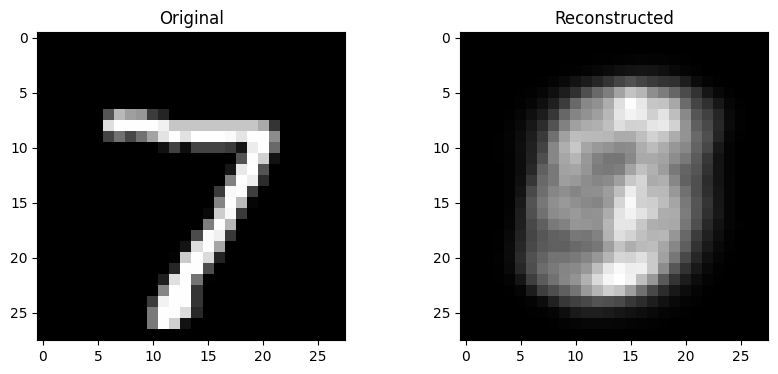

Normal Reconstruction Error: 0.0549
Noise (Outlier) Error: 0.2441


In [8]:
# Visualize Reconstruction
test_img = X_test[0:1]
reconstructed = ae.forward(test_img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(test_img.reshape(28, 28), cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Reconstructed")
plt.imshow(reconstructed.reshape(28, 28), cmap='gray')
plt.show()

# Outlier Detection Test
random_noise = np.random.rand(1, 784)
normal_err, outlier_err = detect_outliers(ae, test_img, random_noise)
print(f"Normal Reconstruction Error: {normal_err[0]:.4f}")
print(f"Noise (Outlier) Error: {outlier_err[0]:.4f}")

Starting MLP Training...
Epoch 0: Loss = 0.9703, Accuracy = 0.8375
Epoch 5: Loss = 0.2986, Accuracy = 0.8970
Epoch 10: Loss = 0.2443, Accuracy = 0.9165
Epoch 15: Loss = 0.2124, Accuracy = 0.9225
Epoch 19: Loss = 0.1665, Accuracy = 0.9305


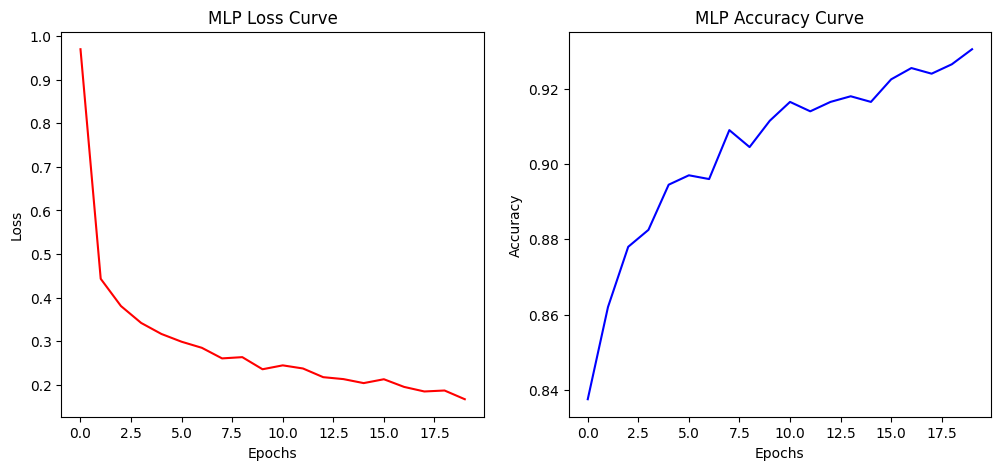

In [9]:
# --- Training MLP ---
mlp = MLP(input_dim=784, hidden_dim=128, output_dim=10, lr=0.1)
epochs = 20
batch_size = 128
history_mlp = {"loss": [], "accuracy": []}

print("Starting MLP Training...")
for epoch in range(epochs):
    # Shuffle training data
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    epoch_loss = []
    # Mini-batch training
    for i in range(0, 10000, batch_size): # Using subset of 10k for speed
        batch_X = X_shuffled[i:i+batch_size]
        batch_y = y_shuffled[i:i+batch_size]
        loss = mlp.train_step(batch_X, batch_y)
        epoch_loss.append(loss)

    # Calculate accuracy on test set
    test_probs = mlp.forward(X_test[:2000])
    predictions = np.argmax(test_probs, axis=1)
    accuracy = np.mean(predictions == y_test[:2000])

    history_mlp["loss"].append(np.mean(epoch_loss))
    history_mlp["accuracy"].append(accuracy)

    if epoch % 5 == 0 or epoch == epochs-1:
        print(f"Epoch {epoch}: Loss = {np.mean(epoch_loss):.4f}, Accuracy = {accuracy:.4f}")

# --- Plotting Results ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp["loss"], label='Training Loss', color='red')
plt.title('MLP Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_mlp["accuracy"], label='Test Accuracy', color='blue')
plt.title('MLP Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()


Starting Autoencoder Training...
Epoch 0: Reconstruction Loss = 0.231657
Epoch 10: Reconstruction Loss = 0.086742
Epoch 20: Reconstruction Loss = 0.074269
Epoch 30: Reconstruction Loss = 0.071305
Epoch 40: Reconstruction Loss = 0.070043


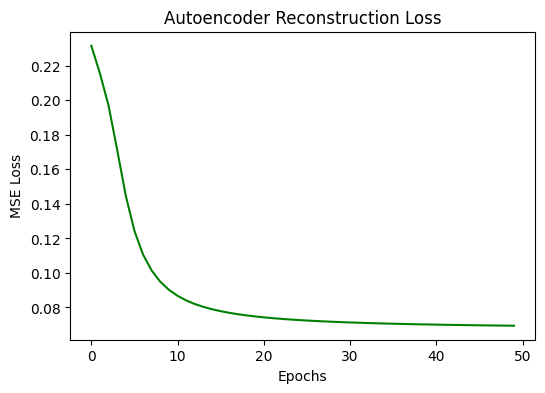

In [10]:
# --- Training Autoencoder ---
# Using a small latent_dim (32) makes it "Undercomplete"
ae = Autoencoder(input_dim=784, latent_dim=32, lr=0.1, l1_reg=0.0001)
history_ae = []

print("\nStarting Autoencoder Training...")
for epoch in range(50):
    loss = ae.train_step(X_train[:5000]) # Training on first 5000 samples
    history_ae.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Reconstruction Loss = {loss:.6f}")

# Plotting AE Loss
plt.figure(figsize=(6, 4))
plt.plot(history_ae, color='green')
plt.title('Autoencoder Reconstruction Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.show()

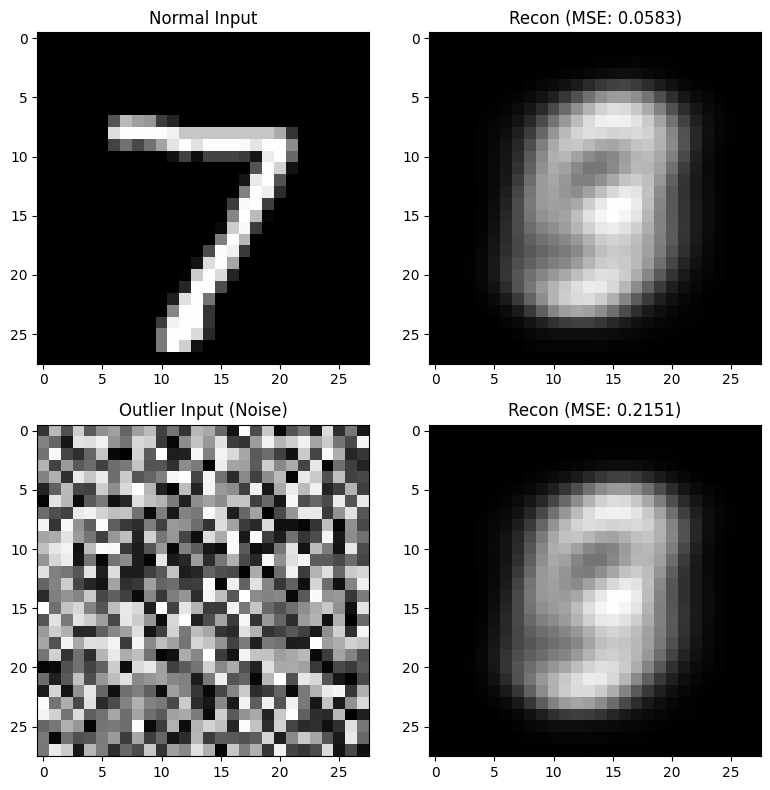

Outlier has 3.7x higher error than the normal digit!


In [11]:
# 1. Take a normal digit (e.g., a '7')
normal_digit = X_test[0:1]
# 2. Generate random noise (the outlier)
outlier_noise = np.random.uniform(0, 1, (1, 784))

# Get Reconstructions
recon_normal = ae.forward(normal_digit)
recon_outlier = ae.forward(outlier_noise)

# Calculate MSE for both
mse_normal = np.mean((normal_digit - recon_normal)**2)
mse_outlier = np.mean((outlier_noise - recon_outlier)**2)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0,0].imshow(normal_digit.reshape(28,28), cmap='gray')
axes[0,0].set_title("Normal Input")
axes[0,1].imshow(recon_normal.reshape(28,28), cmap='gray')
axes[0,1].set_title(f"Recon (MSE: {mse_normal:.4f})")

axes[1,0].imshow(outlier_noise.reshape(28,28), cmap='gray')
axes[1,0].set_title("Outlier Input (Noise)")
axes[1,1].imshow(recon_outlier.reshape(28,28), cmap='gray')
axes[1,1].set_title(f"Recon (MSE: {mse_outlier:.4f})")
plt.tight_layout()
plt.show()

print(f"Outlier has {mse_outlier/mse_normal:.1f}x higher error than the normal digit!")